# Task 3.6 — Step size in Newton’s method (ML: Log-Cosh + L2)

Сравнение стратегий выбора шага для **Ньютона**: `Constant`, `Armijo`, `Wolfe`.

Метрика сходимости (как в 3.5 для ML): относительный квадрат нормы градиента  
\(\|g_k\|^2 / \|g_0\|^2\) в лог-масштабе.

Дополнительно: длины шагов \(\alpha_k\) из `history['alpha']` — момент, с которого **все последующие** шаги равны 1 (зона, где полезен полный ньютоновский шаг).

Newton + ML (Log-Cosh) | start #1
  Const α=1.0      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=0 | ||g|| before k-th step=0.8086769782775446, after=1.380688750115075
  Const α=0.5      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Const α=0.2      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Armijo c1=1e-4   msg=success                iters= 103 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Armijo c1=1e-2   msg=success                iters= 103 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Wolfe c2=0.1     msg=success                iters=   4 | all alpha~=1 from k=1 | ||g|| before k-th step=0.18192757752179958, after=0.014086470636687979
  Wolfe c2=0.9     msg=success                iters=   5 | all alpha~=1 from k=1 | ||g|| before k-th step=0.43205592537356163, after=0.32118144132739435


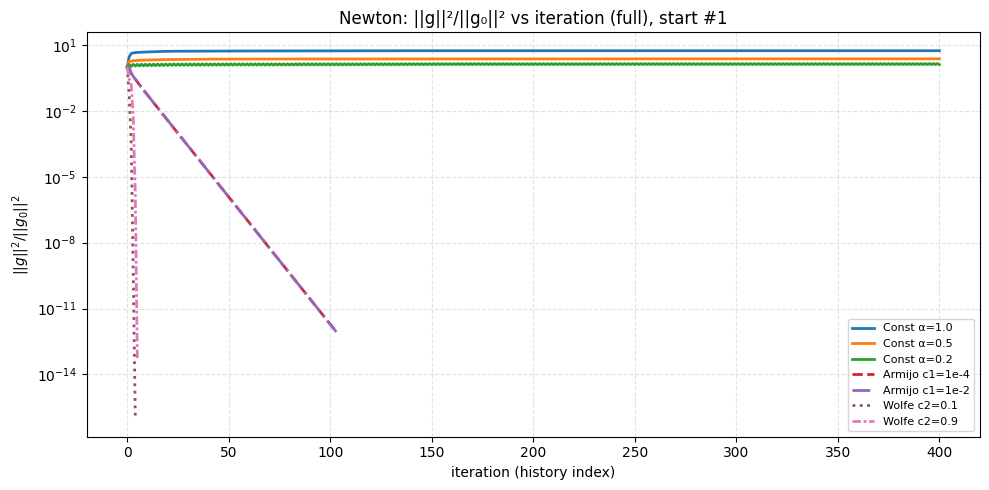

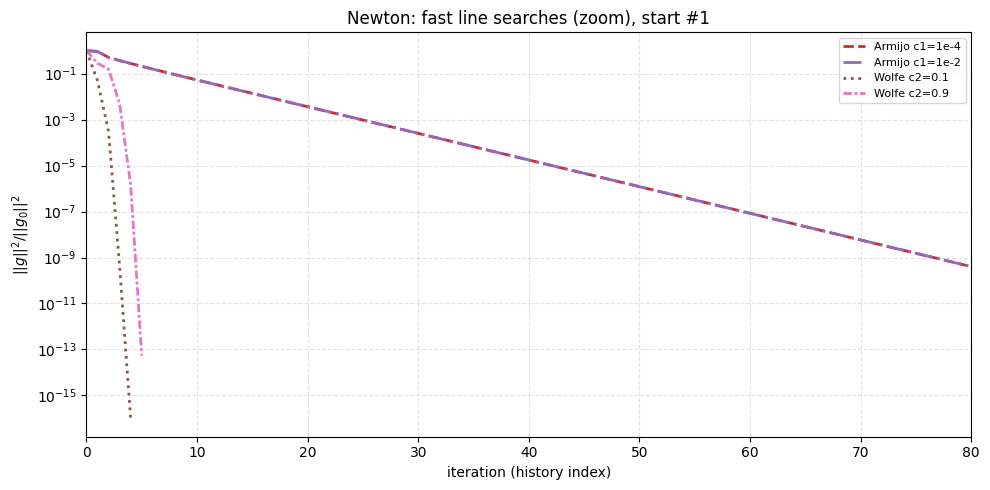

C:\Users\axmed\AppData\Local\Temp\ipykernel_1420\2077387003.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(np.arange(len(a)), a, 'o-', ms=3, lw=1.5, label=name, color=st['color'], ls=st['ls'])


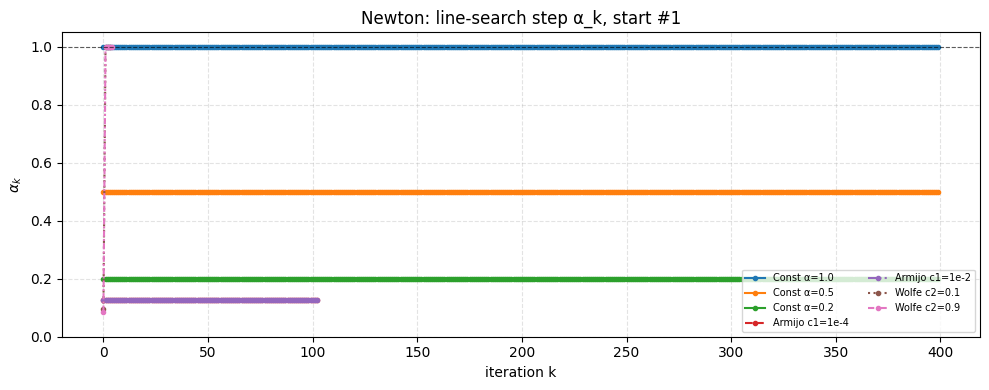

--------------------------------------------------------------------------------
Newton + ML (Log-Cosh) | start #2
  Const α=1.0      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=0 | ||g|| before k-th step=0.9217712389297447, after=1.5714219563288792
  Const α=0.5      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Const α=0.2      msg=iterations_exceeded    iters= 400 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Armijo c1=1e-4   msg=success                iters= 102 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Armijo c1=1e-2   msg=success                iters= 102 | all alpha~=1 from k=None | ||g|| before k-th step=None, after=None
  Wolfe c2=0.1     msg=success                iters=   4 | all alpha~=1 from k=2 | ||g|| before k-th step=0.02437011241227443, after=4.0930277279798165e-05
  Wolfe c2=0.9     msg=success                iters=   5 | all alpha~=1 fr

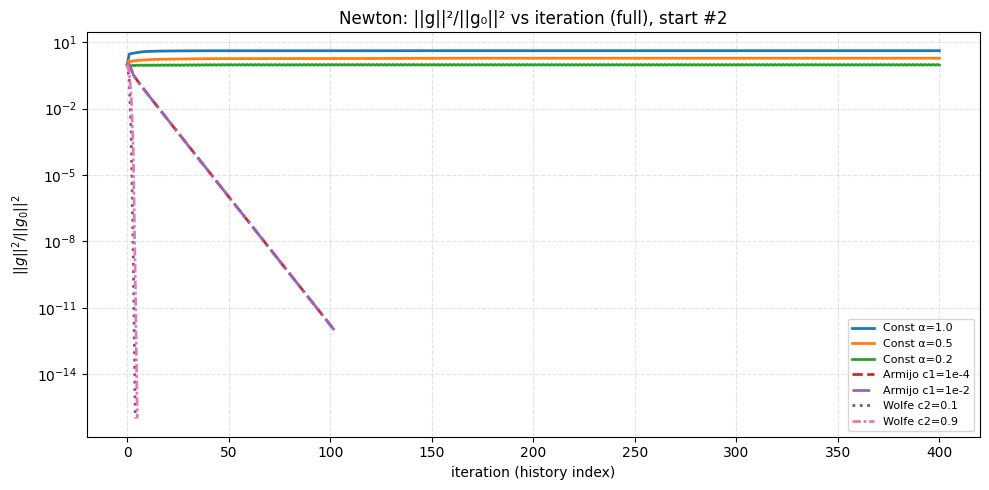

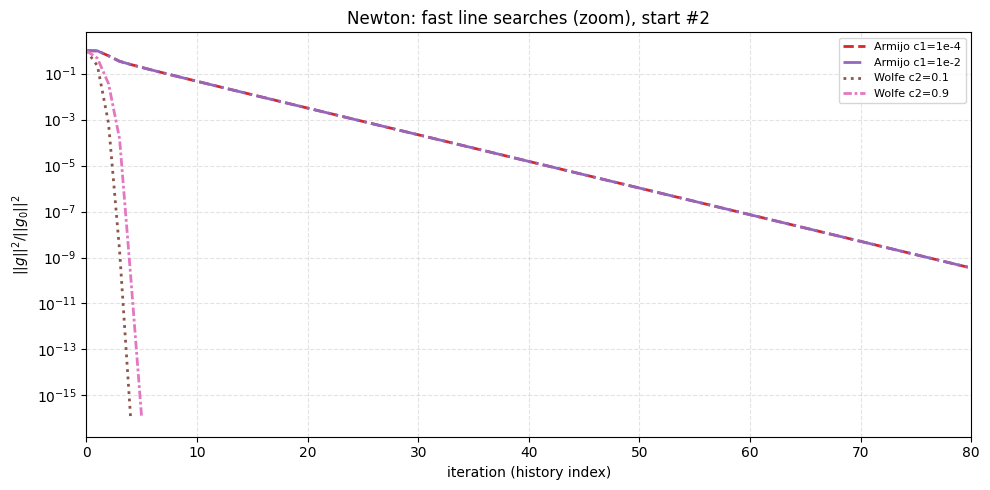

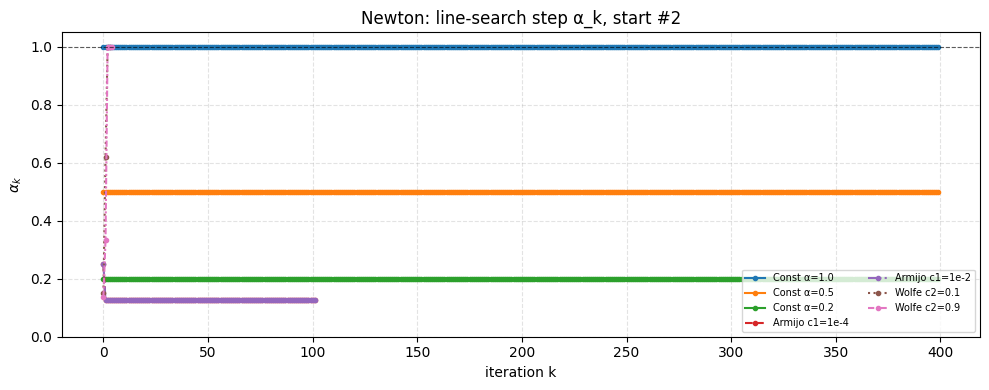

--------------------------------------------------------------------------------


In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.optimization import newton
from src.oracles import LogCoshL2Oracle

np.random.seed(42)


def rel_grad_sq(history):
    g = np.asarray(history['grad_norm'], dtype=float)
    g0_sq = max(g[0] ** 2, 1e-32)
    y = (g ** 2) / g0_sq
    y[~np.isfinite(y)] = np.nan
    return y


def first_index_all_unit_steps(alphas, tol=1e-6):
    """Smallest k such that alpha[j]≈1 for all j>=k; None if never."""
    a = np.asarray(alphas, dtype=float)
    n = len(a)
    if n == 0:
        return None
    for k in range(n):
        if np.all(np.abs(a[k:] - 1.0) <= tol):
            return k
    return None


def run_nt(oracle, x0, line_search_options, tolerance=1e-10, max_iter=500):
    return newton(
        oracle,
        x0,
        tolerance=tolerance,
        max_iter=max_iter,
        line_search_options=line_search_options,
        trace=True,
    )


# ----- ML oracle -----
m, n_features = 1200, 40
X = np.random.randn(m, n_features)
w_true = np.random.randn(n_features)
y = X @ w_true + 0.2 * np.random.randn(m)
regcoef = 1e-2

matvec_Ax = lambda x: X @ x
matvec_ATx = lambda x: X.T @ x
matmat_ATsA = lambda s: X.T @ (s[:, None] * X)

ml_oracle = LogCoshL2Oracle(matvec_Ax, matvec_ATx, matmat_ATsA, y, regcoef)

x0_variants = [
    np.zeros(n_features),
    2.0 * np.ones(n_features),
]

strategies = {
    'Const α=1.0': {'method': 'Constant', 'c': 1.0},
    'Const α=0.5': {'method': 'Constant', 'c': 0.5},
    'Const α=0.2': {'method': 'Constant', 'c': 0.2},
    'Armijo c1=1e-4': {'method': 'Armijo', 'c1': 1e-4, 'alpha_0': 1.0},
    'Armijo c1=1e-2': {'method': 'Armijo', 'c1': 1e-2, 'alpha_0': 1.0},
    'Wolfe c2=0.1': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.1},
    'Wolfe c2=0.9': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9},
}

style = {
    'Const α=1.0': dict(color='C0', ls='-'),
    'Const α=0.5': dict(color='C1', ls='-'),
    'Const α=0.2': dict(color='C2', ls='-'),
    'Armijo c1=1e-4': dict(color='C3', ls='--'),
    'Armijo c1=1e-2': dict(color='C4', ls='-.'),
    'Wolfe c2=0.1': dict(color='C5', ls=':'),
    'Wolfe c2=0.9': dict(color='C6', ls=(0, (3, 1, 1, 1))),
}

for sid, x0 in enumerate(x0_variants, 1):
    curves = {}
    alphas_map = {}
    print(f'Newton + ML (Log-Cosh) | start #{sid}')

    for name, ls_opts in strategies.items():
        x_star, msg, hist = run_nt(ml_oracle, x0, ls_opts, tolerance=1e-12, max_iter=400)
        curves[name] = rel_grad_sq(hist)
        alphas_map[name] = np.asarray(hist.get('alpha', []), dtype=float)
        iters = len(hist['grad_norm']) - 1
        ku = first_index_all_unit_steps(alphas_map[name])
        g_k, g_k1 = None, None
        if ku is not None and ku + 1 < len(hist['grad_norm']):
            g_k = hist['grad_norm'][ku]
            g_k1 = hist['grad_norm'][ku + 1]
        print(
            f'  {name:16s} msg={msg:22s} iters={iters:4d} | '
            f'all alpha~=1 from k={ku} | ||g|| before k-th step={g_k}, after={g_k1}'
        )

    # Relative gradient — full
    plt.figure(figsize=(10, 5))
    for name, y in curves.items():
        st = style[name]
        plt.semilogy(
            np.arange(len(y)),
            np.maximum(y, 1e-16),
            label=name,
            lw=2,
            color=st['color'],
            linestyle=st['ls'],
        )
    plt.title(f'Newton: ||g||²/||g₀||² vs iteration (full), start #{sid}')
    plt.xlabel('iteration (history index)')
    plt.ylabel(r'$||g||^2 / ||g_0||^2$')
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Zoom fast methods
    fast = [k for k in curves if not k.startswith('Const')]
    plt.figure(figsize=(10, 5))
    for name in fast:
        y = curves[name]
        st = style[name]
        plt.semilogy(
            np.arange(len(y)),
            np.maximum(y, 1e-16),
            label=name,
            lw=2,
            color=st['color'],
            linestyle=st['ls'],
        )
    plt.xlim(0, min(80, max((len(curves[k]) for k in fast), default=80)))
    plt.title(f'Newton: fast line searches (zoom), start #{sid}')
    plt.xlabel('iteration (history index)')
    plt.ylabel(r'$||g||^2 / ||g_0||^2$')
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Step sizes α_k
    plt.figure(figsize=(10, 4))
    for name, a in alphas_map.items():
        if len(a) == 0:
            continue
        st = style[name]
        plt.plot(np.arange(len(a)), a, 'o-', ms=3, lw=1.5, label=name, color=st['color'], ls=st['ls'])
    plt.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.6)
    plt.title(f'Newton: line-search step α_k, start #{sid}')
    plt.xlabel('iteration k')
    plt.ylabel(r'$α_k$')
    plt.ylim(0, 1.05)
    plt.grid(True, ls='--', alpha=0.35)
    plt.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

    print('-' * 80)